In [132]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from enum import Enum


class QuestionType(Enum):
    OneToFive = "oneToFive"
    OneToThree = "oneToThree"
    OneToSeven = "oneToSeven"
    TrueFalse = "trueFalse"

# Wczytanie danych z plików CSV
data_1 = pd.read_csv("Data_1.csv")
data_2 = pd.read_csv("Data_2.csv")

# Konwersja wartości "Kobieta" i "Mężczyzna" na "Female" i "Male" w pierwszym zbiorze danych
data_1.replace({"Kobieta": "Female", "Mężczyzna": "Male", "Inne": "Diffrent", "Yes": "1", "No": "0"}, inplace=True)
data_2.replace({"Kobieta": "Female", "Mężczyzna": "Male", "Inne": "Diffrent", "Yes": "1", "No": "0"}, inplace=True)

questions_texts = [
    "Is the text relevant to the prompt?",
    "Does the text take into account the context resulting from the people involved in creating the text (interlocutors)? If so, are they and/or their characteristics referenced correctly?",
    "Does text fit into a wider context? Context of place, story, or events? ",
    "Does the text contain logical contradictions? ",
    "How much do you like this text?"
]

questions_type = [
    QuestionType.OneToFive,
    QuestionType.OneToThree,
    QuestionType.OneToFive,
    QuestionType.TrueFalse,
    QuestionType.OneToSeven
]

data_1_text_origin = [
    "Game",
    "Generated",
    "Generated", 
    "Game",
    "Game",
    "Game",
    "Game",
    "Generated"
]

data_2_text_origin = [
    "Generated",
    "Game",
    "Game", 
    "Generated",
    "Generated",
    "Generated",
    "Generated",
    "Game"
]

texts_names = [
    "D_NilfgardOficer",
    "D_Gounter O'Dim",
    "NO_TresureLetter",
    "NO_NonHuman",
    "N_FindingUma",
    "N_Ge'els",
    "IM_CrachCraite",
    "IM_Sylvan"
]

# Podgląd danych po zmianach
# data_1.head(2), data_2.head(2)
data_1.columns

Index(['Sygnatura czasowa', 'Sex:', 'Age:',
       'Is the text relevant to the prompt?',
       'Does the text take into account the context resulting from the people involved in creating the text (interlocutors)? If so, are they and/or their characteristics referenced correctly?',
       'Does text fit into a wider context? Context of place, story, or events? ',
       'Does the text contain logical contradictions? ',
       'How much do you like this text?',
       'Is the text relevant to the prompt?.1',
       'Does the text take into account the context resulting from the people involved in creating the text (interlocutors)? If so, are they and/or their characteristics referenced correctly?.1',
       'Does text fit into a wider context? Context of place, story, or events? .1',
       'Does the text contain logical contradictions? .1',
       'How much do you like this text?.1',
       'Is the text relevant to the prompt?.2',
       'Does the text take into account the context re

In [133]:
from typing import List


class TextType(Enum):
    DIALOGUE = "dialogue"
    NARRATIVE_OBJECT = "narrative object"
    NARRATION = "narration"
    MENU_TEXT = "menu text"


class Question:
    def __init__(
        self,
        topic: str,
        question: str,
        question_type: QuestionType,
        text_type: TextType,
        text_game: str,
        text_gene: str,
        survey_answers_game: List[int] = None,
        survey_answers_gene: List[int] = None,
    ):
        self.topic = topic
        self.question = question
        self.question_type = question_type
        self.text_type = text_type
        self.text_game = text_game
        self.text_gene = text_gene
        self.survey_answers_game = survey_answers_game or []
        self.survey_answers_gene = survey_answers_gene or []

    def __repr__(self):
        return (
            f"Topic(topic='{self.topic}', question='{self.question}', text_type={self.text_type}, "
            f"text_game='{self.text_game[:30]}...', text_gene='{self.text_gene[:30]}...', "
            f"survey_answers_game={self.survey_answers_game}, survey_answers_gene={self.survey_answers_gene})"
        )
    
    def __str__(self):
        return (
            f"Topic: {self.topic}\n"
            f"Question: {self.question}\n"
            f"Question Type: {self.question_type.value}\n"
            f"Text Type: {self.text_type.value}\n"
            f"Text Game: {self.text_game[:30]}...\n"
            f"Text Generated: {self.text_gene[:30]}...\n"
            f"Survey Answers Game: {self.survey_answers_game}\n"
            f"Survey Answers Generated: {self.survey_answers_gene}\n"
        )



In [134]:
excel_path = "witcher_info.xlsx"  # Change this to your actual file path
xls = pd.ExcelFile(excel_path)

Dialogues_Names = [sheet_name for sheet_name in xls.sheet_names if sheet_name.startswith("D_")] 
Narrative_Objects_Names = [sheet_name for sheet_name in xls.sheet_names if sheet_name.startswith("NO_")]
Narration_Names = [sheet_name for sheet_name in xls.sheet_names if sheet_name.startswith("N_")]
In_Menu_Names = [sheet_name for sheet_name in xls.sheet_names if sheet_name.startswith("IM_")]

research_list = [Dialogues_Names, Narrative_Objects_Names, Narration_Names, In_Menu_Names]

class ResearchObject:
    def __init__(self, context: str, Prompt: str, participants: list, text_game: str, text_llm: str):
        self.context = context
        self.Prompt = Prompt
        self.participants = participants
        self.text_game = text_game
        self.text_llm = text_llm

    def __repr__(self):
        return f"ResearchObject(context={self.context}, Prompt={self.Prompt}, participants={self.participants}, text_game={self.text_game}, text_llm={self.text_llm})"
    
    def get_texts(self):
        Participants_Text = "" 
        for i in range(len(self.participants)):
            Participants_Text.join(str(self.participants[i]))
        return [self.context, self.Prompt, self.text_game, self.text_llm, Participants_Text]

def create_research_object(xls, sheet_name: str) -> ResearchObject:
    df = pd.read_excel(xls, sheet_name=sheet_name)
    selected_columns = df[['Context', 'Prompt', 'Participants', 'Text Game', 'Text LLM']].copy()
    selected_columns.columns = ['Context', 'Prompt', 'Participants', 'Text Game', 'Text LLM']

    context = selected_columns['Context'].get(0)
    Prompt = selected_columns['Prompt'].get(0)
    text_game = selected_columns['Text Game'].get(0)
    text_llm = selected_columns['Text LLM'].get(0)
    participants = selected_columns['Participants']
    
    return ResearchObject(context, Prompt, participants, text_game, text_llm)

In [135]:
research_objects: list = []
for sheet_name in xls.sheet_names:
    if sheet_name.startswith("D_") or sheet_name.startswith("NO_") or sheet_name.startswith("N_") or sheet_name.startswith("IM_"):
        research_objects.append(create_research_object(xls, sheet_name))

questions = []

for i, text_name in enumerate(texts_names):
    for j, question_text in enumerate(questions_texts):
        if text_name.startswith("D_"):
            text_type = TextType.DIALOGUE
        elif text_name.startswith("NO_"):
            text_type = TextType.NARRATIVE_OBJECT
        elif text_name.startswith("N_"):
            text_type = TextType.NARRATION
        elif text_name.startswith("IM_"):
            text_type = TextType.MENU_TEXT
        else:
            continue

        question_coloumn = question_text + str("" if i==0 else f".{i}")

        question = Question(
            topic=text_name,
            question=question_text,
            question_type=questions_type[j],
            text_type=text_type,
            text_game=research_objects[i].text_game,
            text_gene=research_objects[i].text_llm,
            survey_answers_game=data_1[question_coloumn].tolist(),
            survey_answers_gene=data_2[question_coloumn].tolist()
        )
        questions.append(question)

for question in questions:
    print(question)
    print("-" * 1000)

Topic: D_NilfgardOficer
Question: Is the text relevant to the prompt?
Question Type: oneToFive
Text Type: dialogue
Text Game: Geralt: Geralt of Rivia. Witch...
Text Generated: Geralt: "I'm looking for a sor...
Survey Answers Game: [4, 5, 5, 1, 5, 5, 5, 4, 5, 1, 5, 5, 5, 5, 5]
Survey Answers Generated: [5, 4, 5, 5, 5, 5, 4, 5, 3, 4, 5, 5, 5, 3, 5]

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

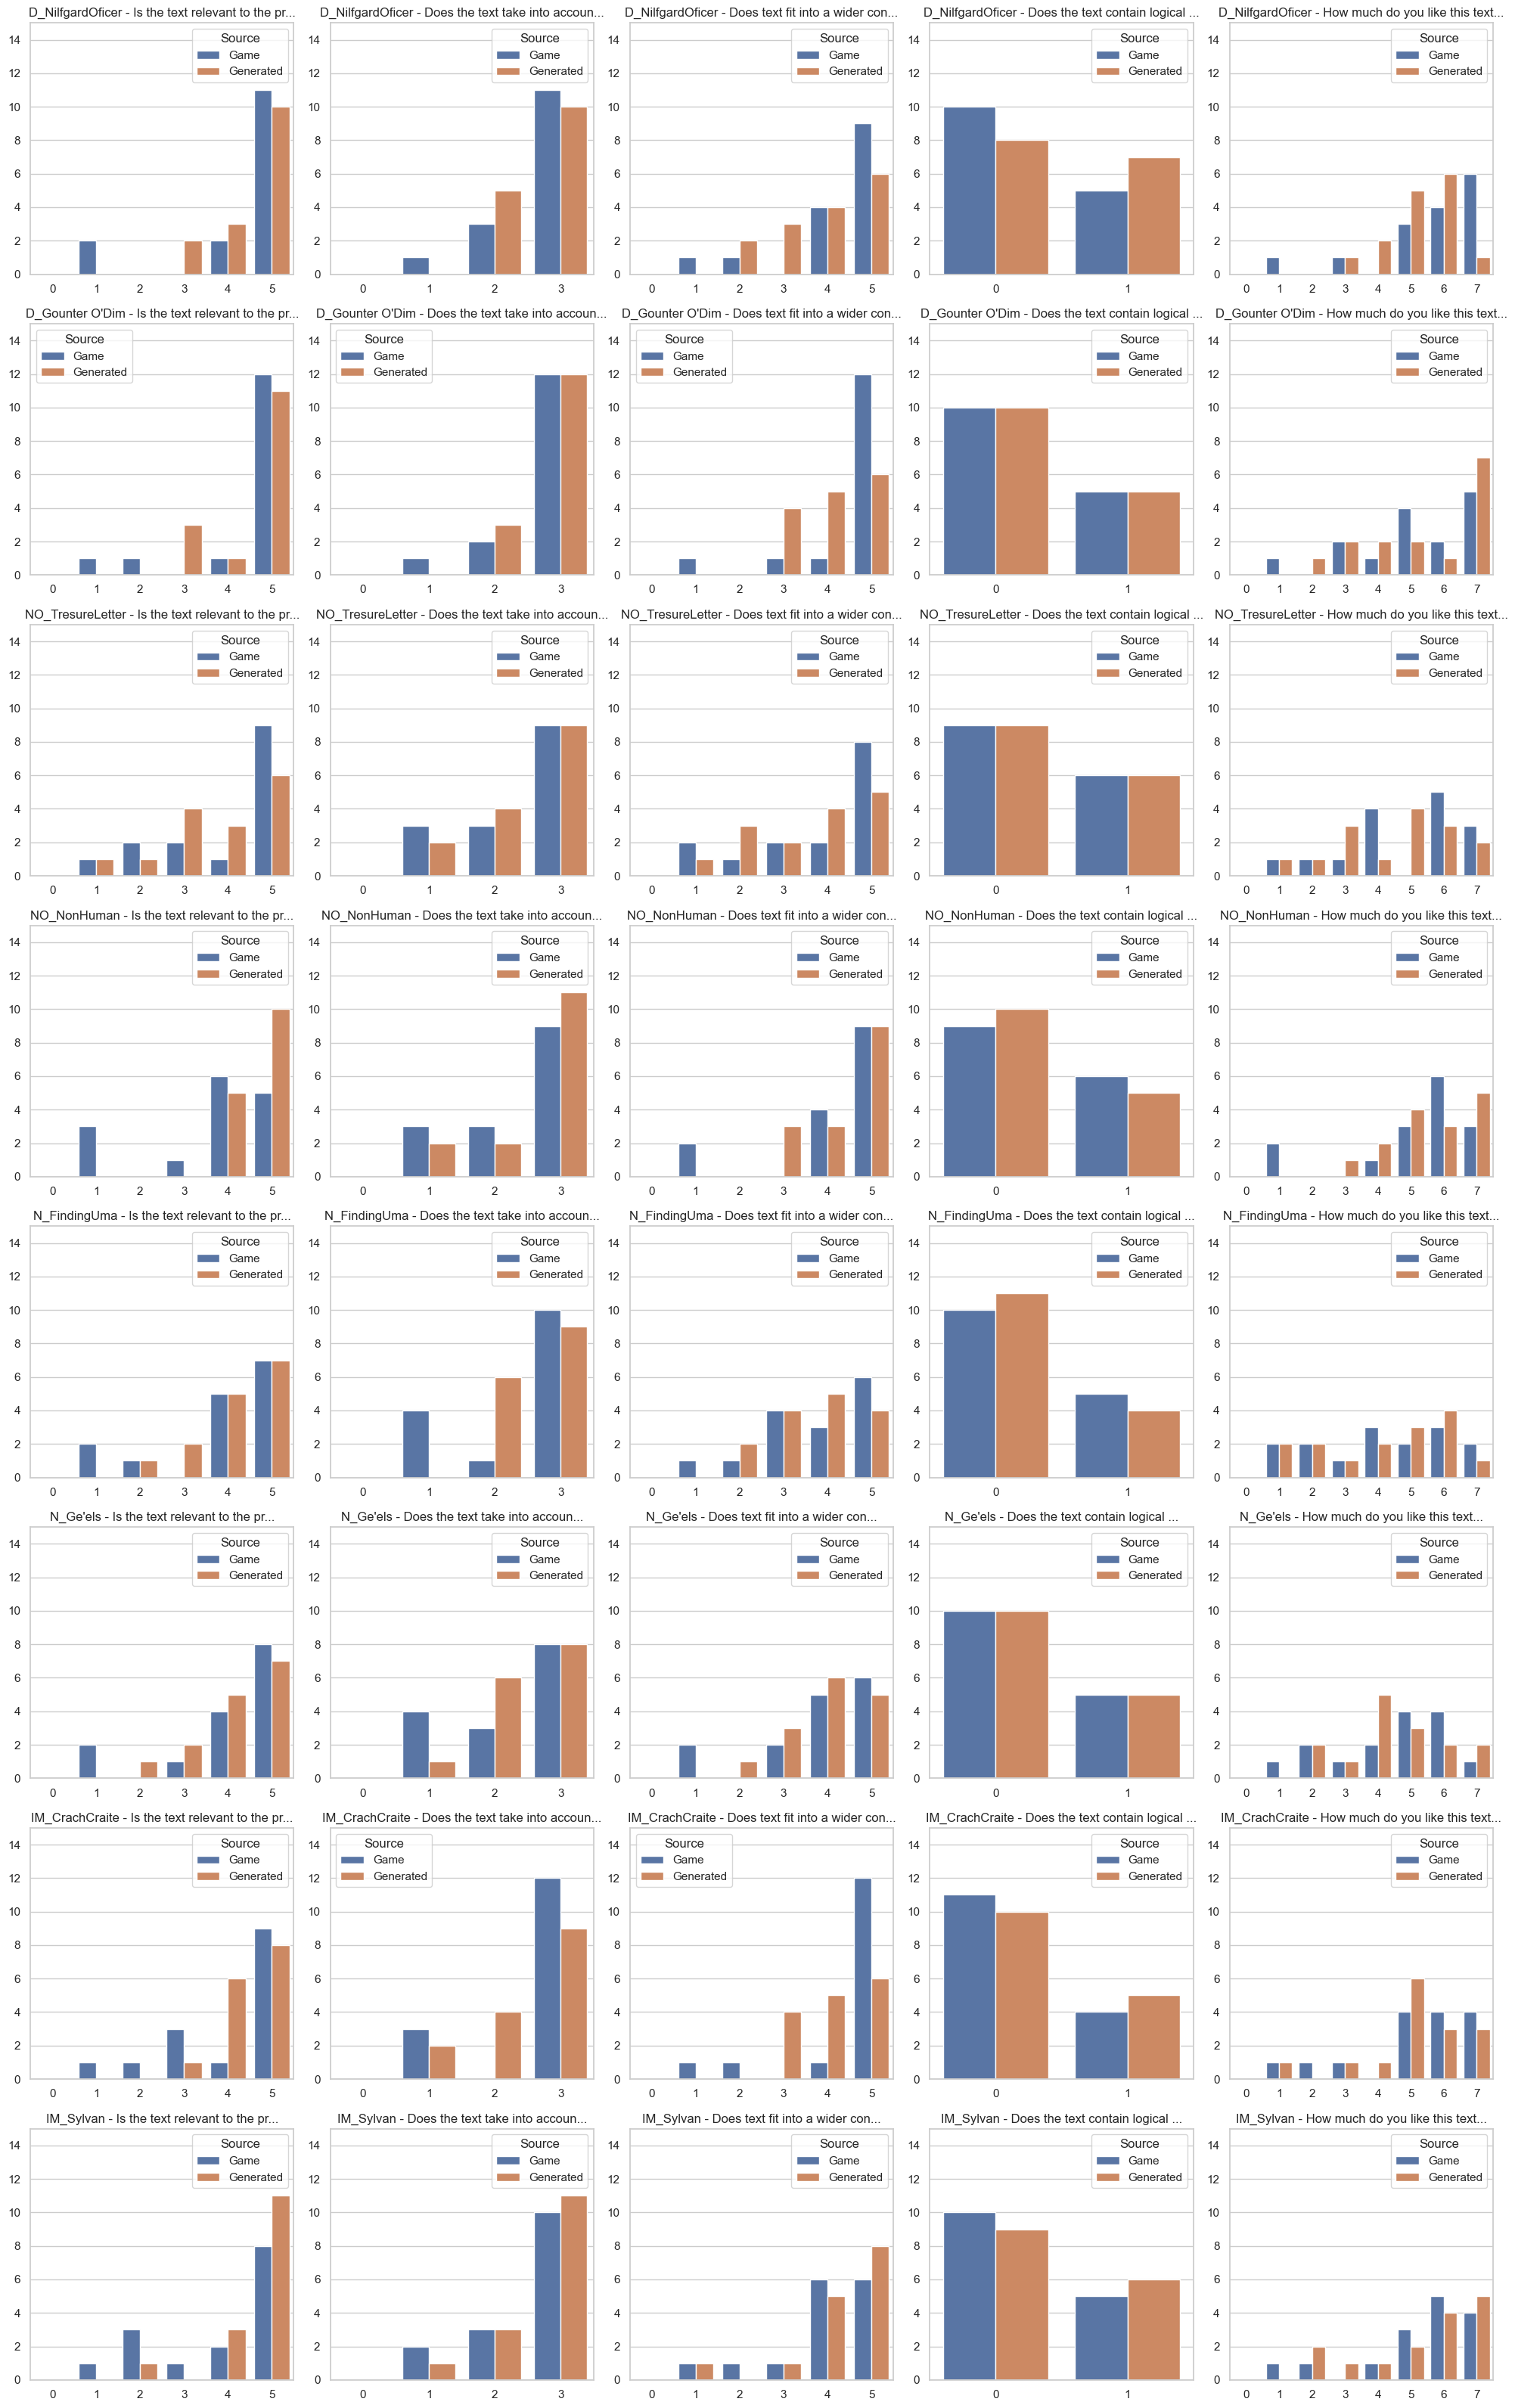

In [136]:
rows, cols = 8, 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
sns.set(style="whitegrid")

for i, (q, ax) in enumerate(zip(questions, axes.flat)):
    # Zakres odpowiedzi ustalony ręcznie (np. 0-4), możesz też obliczać z danych
    if q.question_type == QuestionType.OneToFive:
        bins = list(range(0, 6))
    elif q.question_type == QuestionType.OneToThree:
        bins = list(range(0, 4))
    elif q.question_type == QuestionType.OneToSeven:
        bins = list(range(0, 8))
    elif q.question_type == QuestionType.TrueFalse:
        bins = list(range(0, 2))
    else:
        bins = list(range(0, 5))

    

    game_series = pd.Series(q.survey_answers_game, name="Game")
    gene_series = pd.Series(q.survey_answers_gene, name="Generated")
    combined_df = pd.concat([game_series, gene_series], axis=1)
    combined_df.columns = ["Game", "Generated"]
    combined_df = combined_df.melt(var_name="Source", value_name="Score")

    sns.countplot(data=combined_df, x="Score", hue="Source", order=bins, ax=ax)
    ax.set_title(q.topic + " - " + q.question[:30] + "...")
    ax.set_xticks(bins)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Stała skala Y: od 0 do liczby odpowiedzi (bo każdy typ ma tyle samo)
    max_y = max(len(q.survey_answers_game), len(q.survey_answers_gene))
    ax.set_ylim(0, max_y)

# Ukrycie pustych wykresów jeśli questions < 40
for j in range(i + 1, rows * cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()


4.2.	Analysis of participants evaluation - comparison of generated and original texts

In [137]:
import numpy as np
from scipy.stats import mannwhitneyu
import pandas as pd

# Lista do przechowania wyników statystycznych
statistical_results = []

# Przypisanie nazw uproszczonych do czterech głównych cech
key_question_labels = {
    "Is the text relevant to the prompt?": "Prompt relevance",
    "Does the text take into account the context resulting from the people involved in creating the text (interlocutors)? If so, are they and/or their characteristics referenced correctly?": "Context relevance",
    "Does text fit into a wider context? Context of place, story, or events? ": "Pragmatic coherence",
    "How much do you like this text?": "Human-likeness"
}


for q in questions:
    if q.question in key_question_labels:
        # Konwersja odpowiedzi na liczby całkowite
        game_scores = pd.to_numeric(q.survey_answers_game, errors='coerce').astype(int)
        gene_scores = pd.to_numeric(q.survey_answers_gene, errors='coerce').astype(int)

        if len(game_scores) == 0 or len(gene_scores) == 0:
            continue  # pomiń puste dane

        # Test Manna-Whitneya
        u_stat, p_value = mannwhitneyu(gene_scores, game_scores, alternative='two-sided')

        # Dodatkowe statystyki
        n1, n2 = len(gene_scores), len(game_scores)
        mu_U = n1 * n2 / 2
        sigma_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
        Z = (u_stat - mu_U) / sigma_U

        statistical_results.append({
            "Topic": q.topic,
            "Characteristic": key_question_labels[q.question],
            "N_generated": n1,
            "N_game": n2,
            "U_statistic": u_stat,
            "Z_score": Z,
            "p_value": p_value
        })

# Stworzenie DataFrame z wynikami
results_df = pd.DataFrame(statistical_results)

results_df

,Topic,Characteristic,N_generated,N_game,U_statistic,Z_score,p_value
0,D_NilfgardOficer,Prompt relevance,15,15,108.0,-0.186651,0.837264
1,D_NilfgardOficer,Context relevance,15,15,107.5,-0.207390,0.815335
2,D_NilfgardOficer,Pragmatic coherence,15,15,88.0,-1.016213,0.281653
3,D_NilfgardOficer,Human-likeness,15,15,77.0,-1.472471,0.132581
4,D_Gounter O'Dim,Prompt relevance,15,15,107.5,-0.207390,0.801042
5,D_Gounter O'Dim,Context relevance,15,15,114.0,0.062217,0.952452
6,D_Gounter O'Dim,Pragmatic coherence,15,15,72.5,-1.659123,0.062257
7,D_Gounter O'Dim,Human-likeness,15,15,120.5,0.331825,0.746298
8,NO_TresureLetter,Prompt relevance,15,15,98.0,-0.601432,0.532220
9,NO_TresureLetter,Context relevance,15,15,115.5,0.124434,0.905781


4.3.	Analysis of participants evaluation - comparison of text categories


In [138]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from collections import defaultdict

# Map enum to category name
text_category_labels = {
    "dialogue": "Dialogue/Monologue",
    "narrative object": "Narrative artifact",
    "narration": "Narrator text",
    "menu text": "In-menu text"
}

# Prepare results
kruskal_results = []

for question_text, label in key_question_labels.items():
    # Group answers by text category
    grouped_scores = defaultdict(list)

    for q in questions:
        if q.question == question_text:
            category_name = text_category_labels[q.text_type.value]
            # game_scores = pd.to_numeric(q.survey_answers_game, errors='coerce').astype(int)
            gene_scores = pd.to_numeric(q.survey_answers_gene, errors='coerce').astype(int)
            # grouped_scores[category_name].extend(game_scores)
            grouped_scores[category_name].extend(gene_scores)

    # Only run the test if all 4 groups are present and non-empty
    if len(grouped_scores) == 4 and all(len(g) > 0 for g in grouped_scores.values()):
        # Prepare inputs
        groups = [grouped_scores[key] for key in sorted(grouped_scores.keys())]
        H_stat, p_value = kruskal(*groups)

        kruskal_results.append({
            "Characteristic": label,
            "H_statistic": H_stat,
            "p_value": p_value,
            "N_total": sum(len(g) for g in groups),
            "Group_sizes": {k: len(v) for k, v in grouped_scores.items()}
        })

# Convert to DataFrame
kruskal_df = pd.DataFrame(kruskal_results)


for i in kruskal_df["Group_sizes"]:
    print(i)
kruskal_df

{'Dialogue/Monologue': 30, 'Narrative artifact': 30, 'Narrator text': 30, 'In-menu text': 30}
{'Dialogue/Monologue': 30, 'Narrative artifact': 30, 'Narrator text': 30, 'In-menu text': 30}
{'Dialogue/Monologue': 30, 'Narrative artifact': 30, 'Narrator text': 30, 'In-menu text': 30}
{'Dialogue/Monologue': 30, 'Narrative artifact': 30, 'Narrator text': 30, 'In-menu text': 30}


,Characteristic,H_statistic,p_value,N_total,Group_sizes
0,Prompt relevance,3.885943,0.274047,120,"{'Dialogue/Monologue': 30, 'Narrative artifact..."
1,Context relevance,1.846095,0.604956,120,"{'Dialogue/Monologue': 30, 'Narrative artifact..."
2,Pragmatic coherence,2.087529,0.554440,120,"{'Dialogue/Monologue': 30, 'Narrative artifact..."
3,Human-likeness,5.996528,0.111779,120,"{'Dialogue/Monologue': 30, 'Narrative artifact..."


In [139]:
# For a specific characteristic, e.g. "Human-likeness"
import pandas as pd
from collections import defaultdict

char = questions_texts[4]   # "Human-likeness"
group_scores = defaultdict(list)

for q in questions:
    if q.question == char:
        category = text_category_labels[q.text_type.value]
        group_scores[category].extend(pd.to_numeric(q.survey_answers_game, errors='coerce').astype(int))
        group_scores[category].extend(pd.to_numeric(q.survey_answers_gene, errors='coerce').astype(int))

# Calculate mean or median
summary = {k: {
    "mean": round(np.mean(v), 2),
    "median": round(np.median(v), 2),
    "n": len(v)
} for k, v in group_scores.items()}

pd.DataFrame.from_dict(summary, orient='index')


,mean,median,n
Dialogue/Monologue,5.38,6.0,60
Narrative artifact,5.05,5.5,60
Narrator text,4.35,5.0,60
In-menu text,5.25,6.0,60
